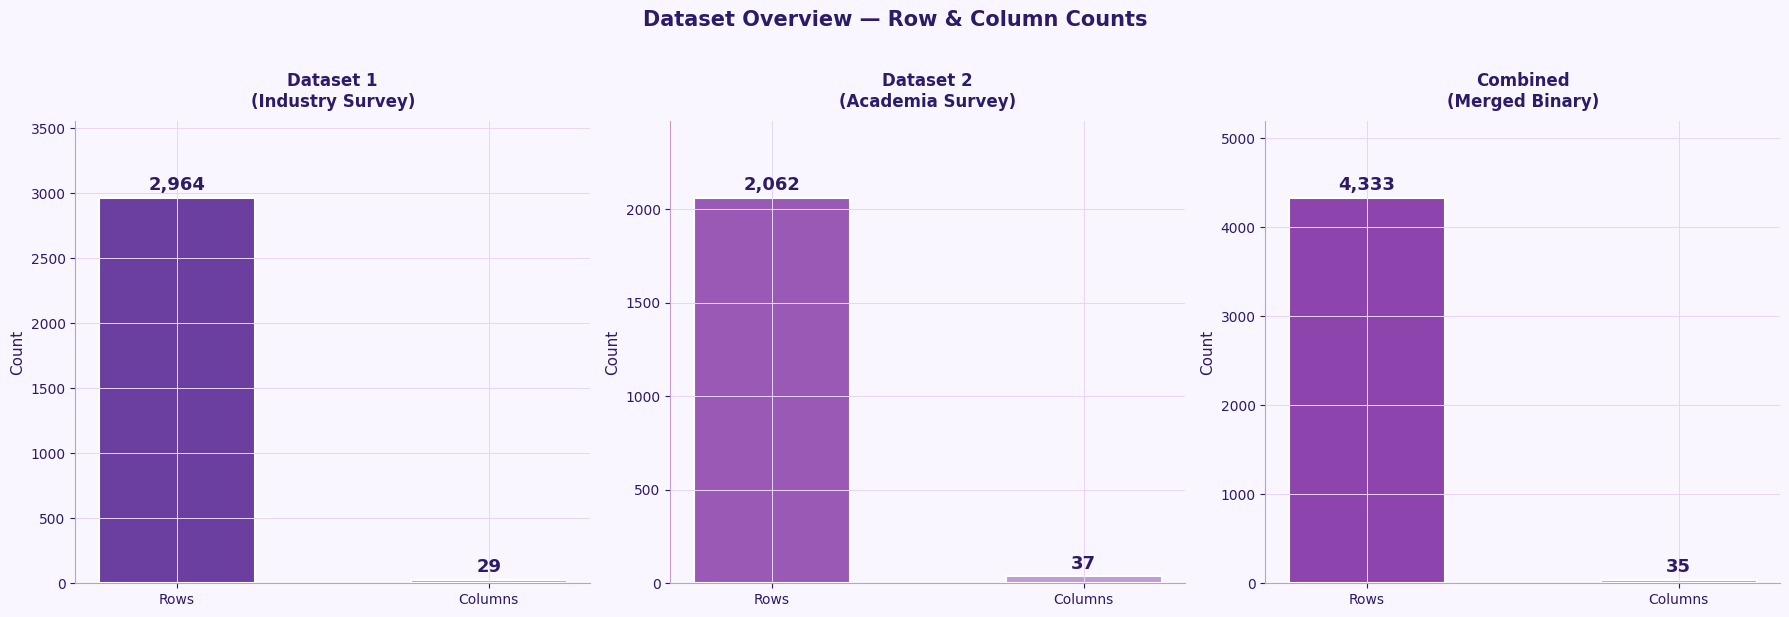

Figure 1 saved ✓


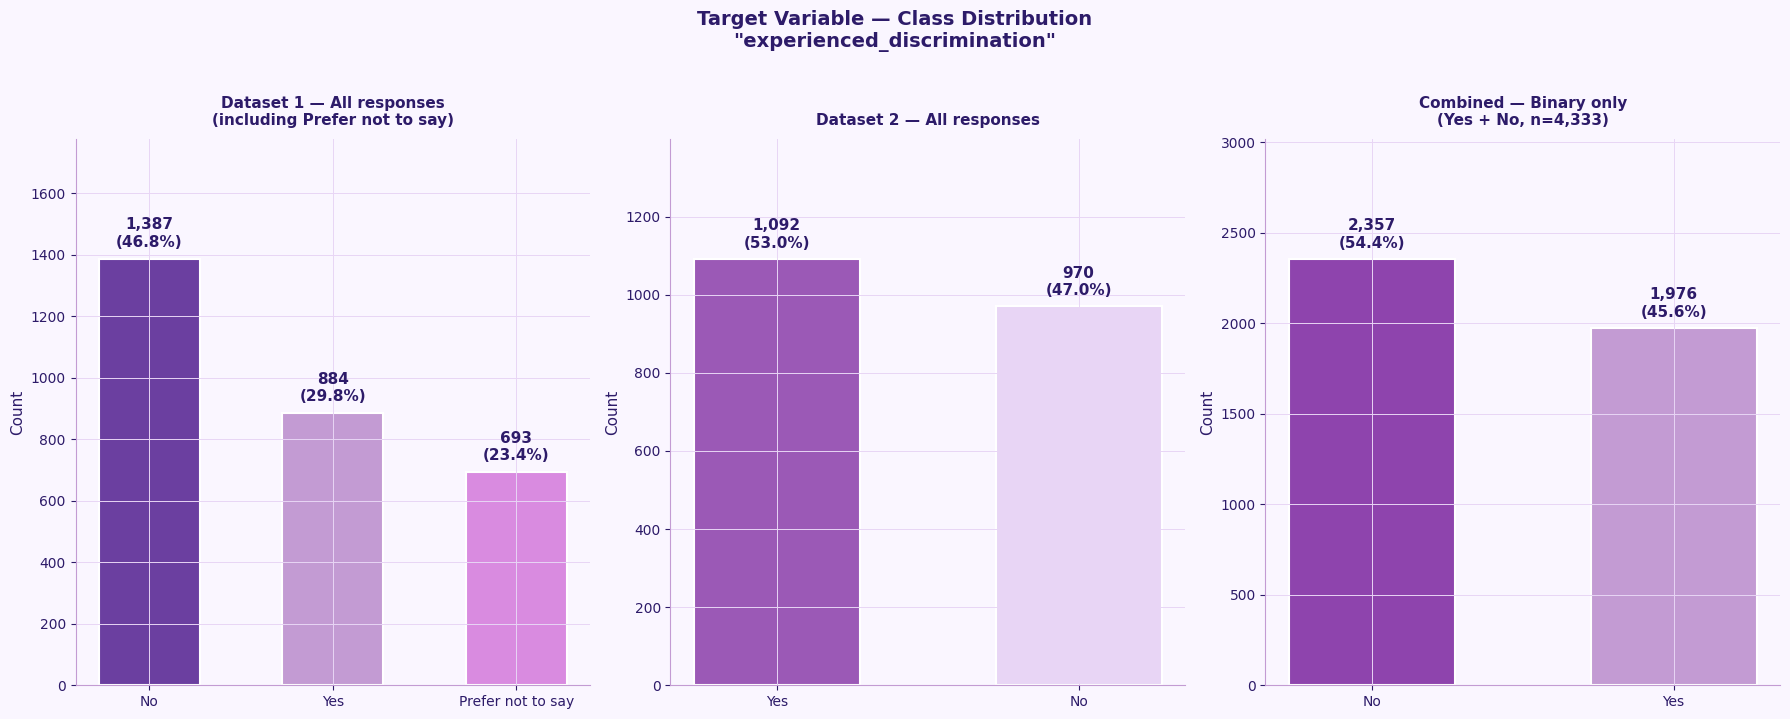

Figure 2 saved ✓


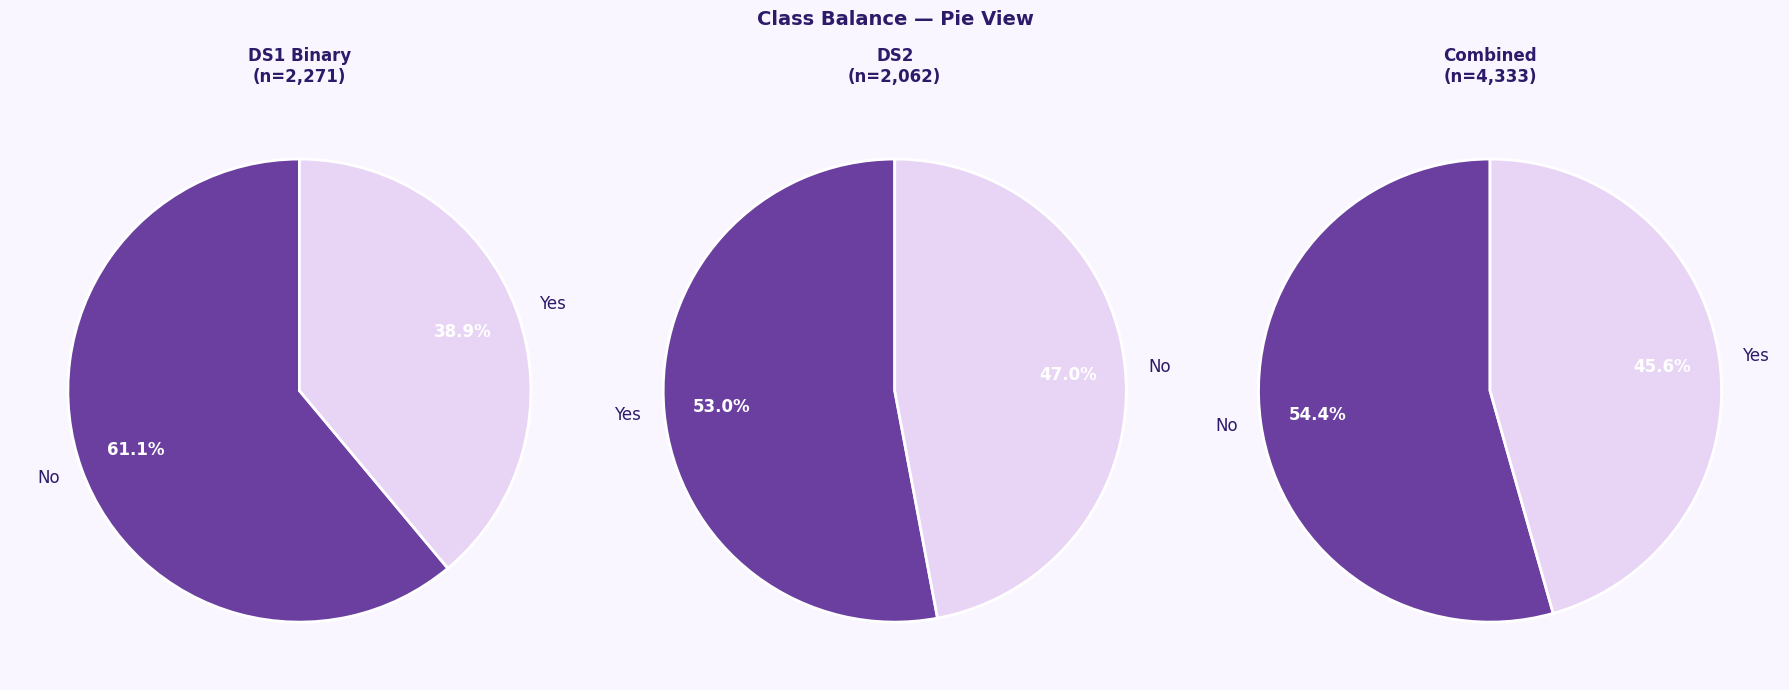

Figure 3 saved ✓


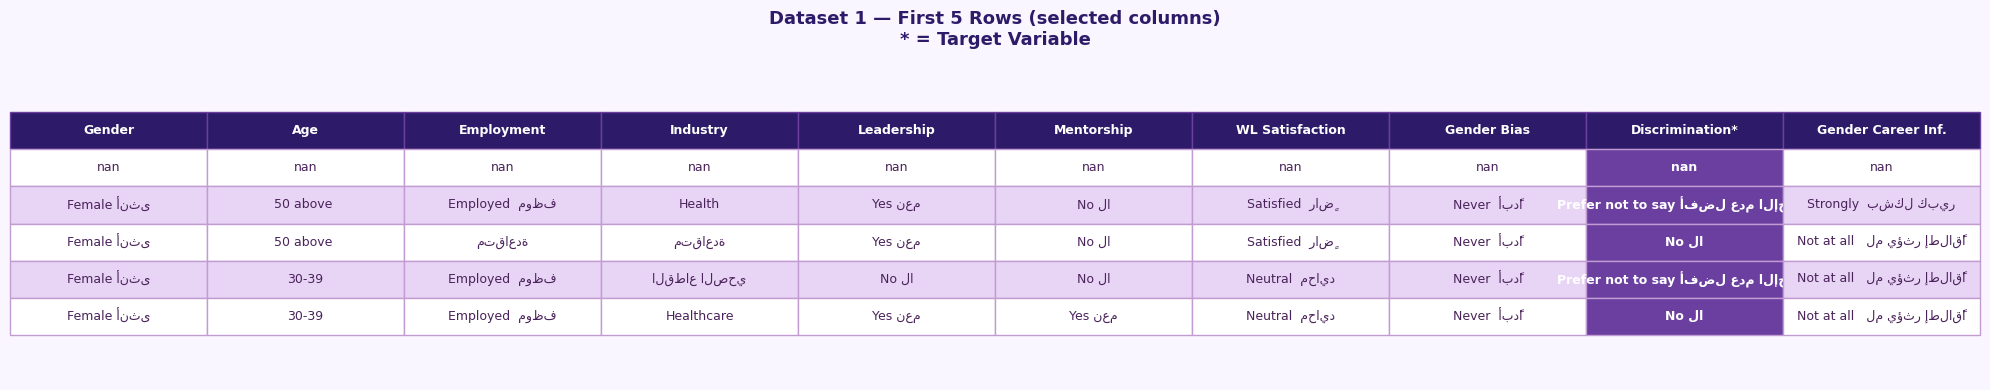

Figure 4 saved ✓


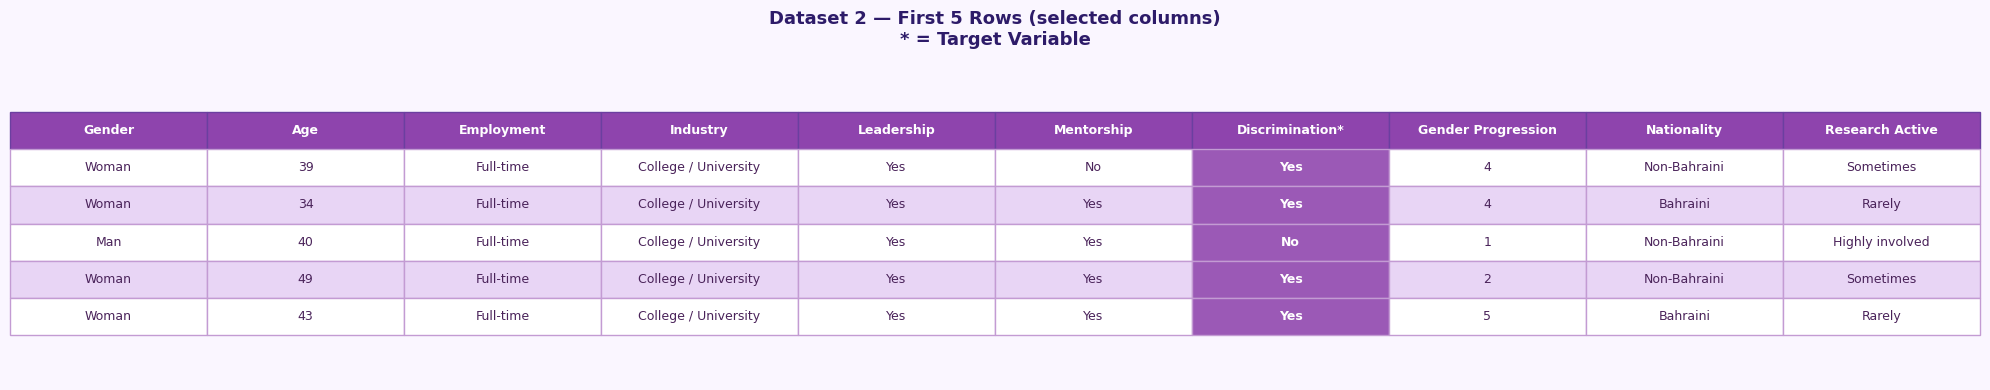

Figure 5 saved ✓


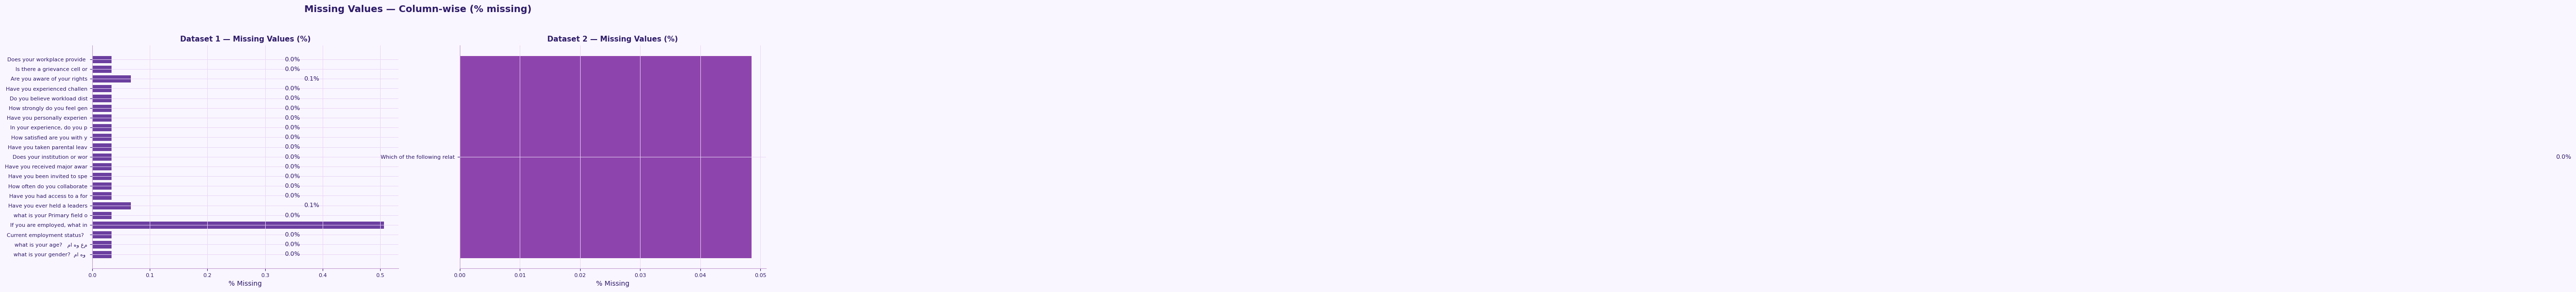

Figure 6 saved ✓


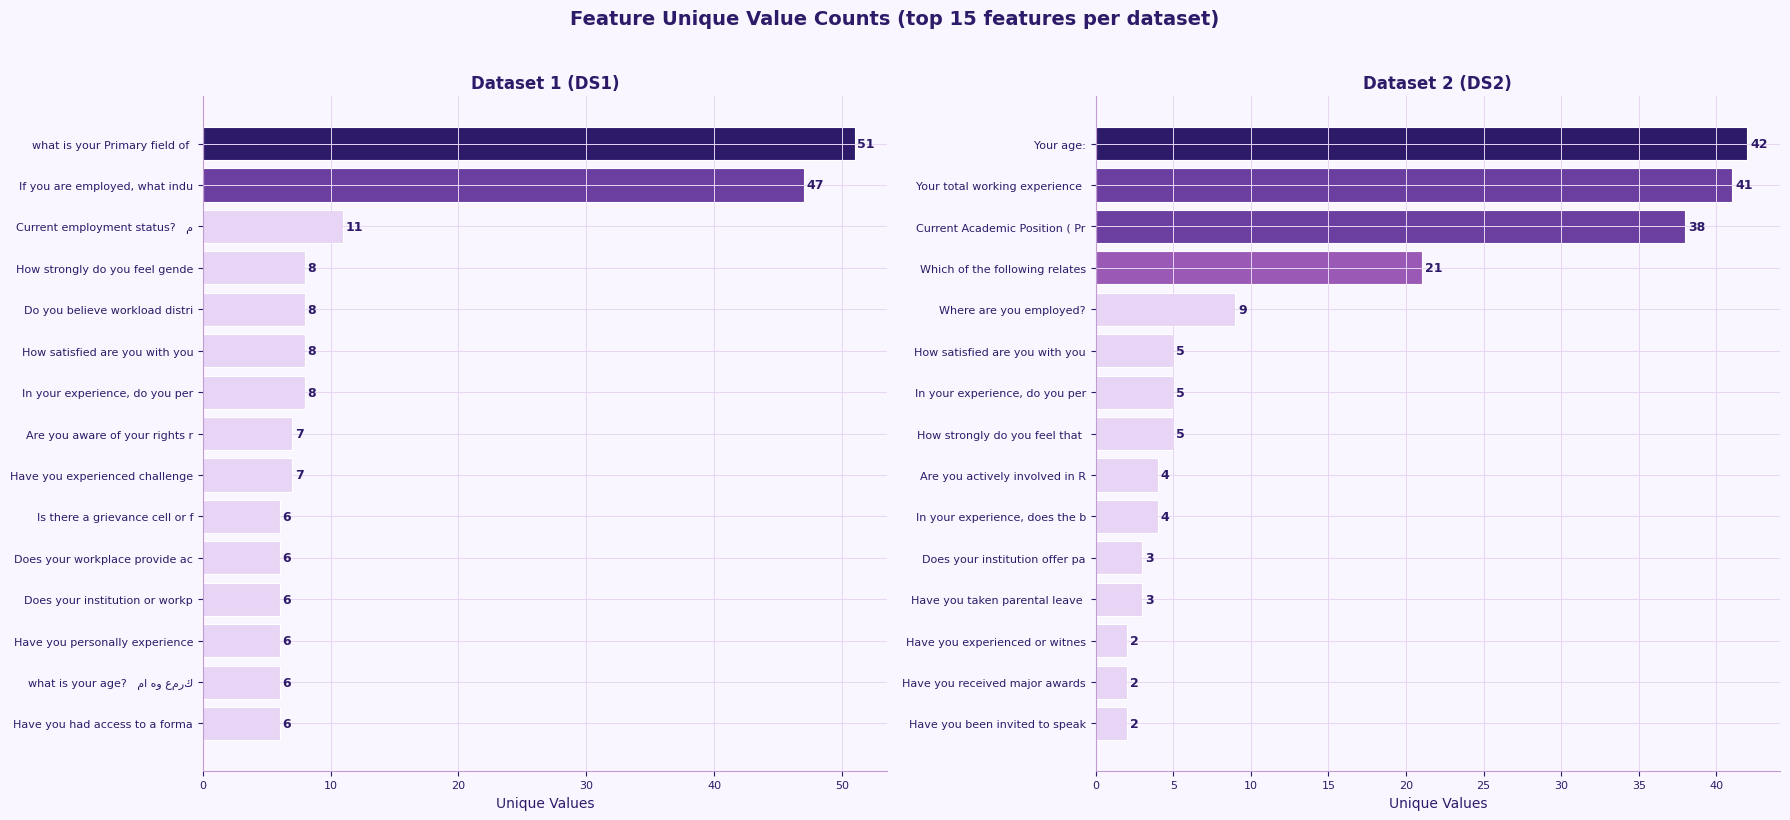

Figure 7 saved ✓


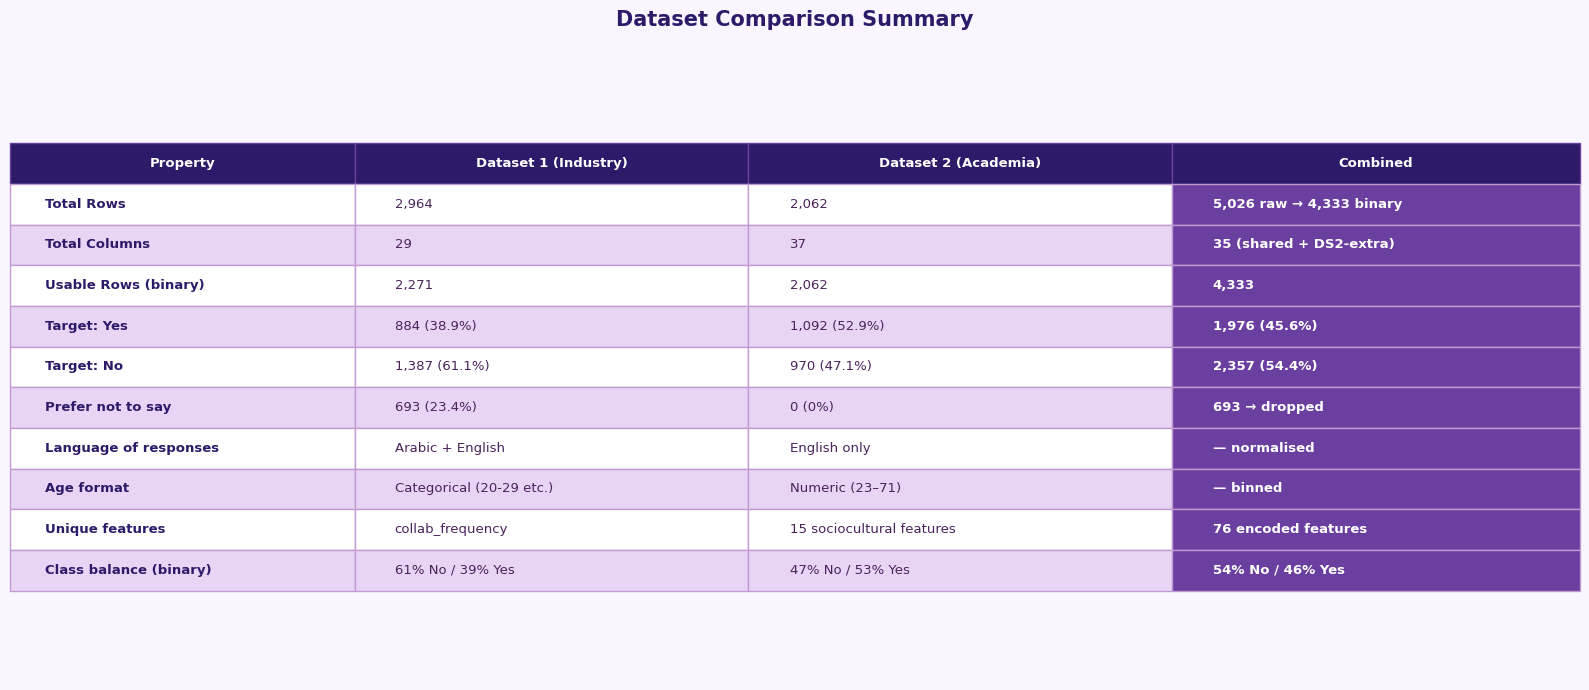

Figure 8 saved ✓

✅ All 8 overview figures generated successfully
Saved: overview_1_shape.png through overview_8_summary_table.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
# DATASET OVERVIEW — Both Datasets Individually and Combined
# Colours: shades of purple throughout
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Purple palette ────────────────────────────────────────────────
P = {
    'dark':    '#2D1B69',   # deep indigo
    'mid':     '#6B3FA0',   # rich purple
    'bright':  '#9B59B6',   # medium purple
    'soft':    '#C39BD3',   # soft lavender
    'pale':    '#E8D5F5',   # very pale lilac
    'pink':    '#D98BE0',   # pink-purple
    'deep':    '#4A235A',   # near-black purple
    'accent':  '#8E44AD',   # vivid purple
}
PURPLES = [P['dark'], P['mid'], P['bright'], P['soft'], P['pink'], P['pale'], P['accent'], P['deep']]
BG      = '#FAF6FF'         # off-white with purple tint
GRID    = '#E8D5F5'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.facecolor':    BG,
    'figure.facecolor':  BG,
    'axes.grid':         True,
    'grid.color':        GRID,
    'grid.linewidth':    0.7,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  True,
    'axes.spines.bottom':True,
    'axes.edgecolor':    P['soft'],
})

# ── Load data ─────────────────────────────────────────────────────
df1 = pd.read_excel('Survey on Gender Equality in Industries Across Bahrain.xlsx')
df2 = pd.read_excel('Survey on Gender Equality in Academia Across Bahrain.xlsx')

# Quick rename for target columns only (for labelling)
TARGET_COL_DS1 = df1.columns[20]
TARGET_COL_DS2 = 'Have you experienced or witnessed gender-based discrimination at any point in your academic career? '

# Normalise DS1 target
def norm_target(val):
    s = str(val).strip()
    for yes in ['Yes', 'Yes نعم', 'Yes\xa0نعم']:
        if yes in s: return 'Yes'
    for no in ['No', 'No لا', 'No\xa0لا']:
        if no in s: return 'No'
    return 'Prefer not to say'

ds1_target = df1[TARGET_COL_DS1].apply(norm_target)
ds2_target = df2[TARGET_COL_DS2].str.strip()

# Combined (binary only)
ds1_binary = ds1_target[ds1_target.isin(['Yes','No'])]
ds2_binary = ds2_target[ds2_target.isin(['Yes','No'])]
combined_target = pd.concat([ds1_binary, ds2_binary], ignore_index=True)


# ══════════════════════════════════════════════════════════════════
# FIGURE 1 — Basic stats panel (3 datasets side by side)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Dataset Overview — Row & Column Counts', fontsize=15, fontweight='bold',
             color=P['dark'], y=1.02)

datasets = [
    ('Dataset 1\n(Industry Survey)', df1.shape[0], df1.shape[1], P['mid']),
    ('Dataset 2\n(Academia Survey)', df2.shape[0], df2.shape[1], P['bright']),
    ('Combined\n(Merged Binary)', 4333, 35, P['accent']),
]

for ax, (label, rows, cols, color) in zip(axes, datasets):
    ax.set_facecolor(BG)
    ax.bar(['Rows', 'Columns'], [rows, cols], color=[color, P['soft']],
           edgecolor='white', linewidth=1.5, width=0.5)
    ax.set_title(label, fontsize=12, fontweight='bold', color=P['dark'], pad=10)
    ax.set_ylabel('Count', fontsize=11, color=P['dark'])
    for i, v in enumerate([rows, cols]):
        ax.text(i, v + rows * 0.01, f'{v:,}', ha='center', va='bottom',
                fontsize=13, fontweight='bold', color=P['dark'])
    ax.tick_params(colors=P['dark'])
    ax.set_ylim(0, max(rows, cols) * 1.2)
    ax.spines['left'].set_color(P['soft'])
    ax.spines['bottom'].set_color(P['soft'])

plt.tight_layout()
plt.savefig('overview_1_shape.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 1 saved ✓')


# ══════════════════════════════════════════════════════════════════
# FIGURE 2 — Class imbalance (all 3 versions)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Target Variable — Class Distribution\n"experienced_discrimination"',
             fontsize=14, fontweight='bold', color=P['dark'], y=1.02)

panel_data = [
    ('Dataset 1 — All responses\n(including Prefer not to say)', ds1_target.value_counts(),
     [P['mid'], P['soft'], P['pink']]),
    ('Dataset 2 — All responses', ds2_binary.value_counts(),
     [P['bright'], P['pale']]),
    ('Combined — Binary only\n(Yes + No, n=4,333)', combined_target.value_counts(),
     [P['accent'], P['soft']]),
]

for ax, (title, vc, colors) in zip(axes, panel_data):
    ax.set_facecolor(BG)
    total = vc.sum()
    bars = ax.bar(vc.index, vc.values, color=colors[:len(vc)],
                  edgecolor='white', linewidth=1.5, width=0.55)
    for bar, v in zip(bars, vc.values):
        pct = v / total * 100
        ax.text(bar.get_x() + bar.get_width()/2, v + total * 0.01,
                f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color=P['dark'])
    ax.set_title(title, fontsize=11, fontweight='bold', color=P['dark'], pad=10)
    ax.set_ylabel('Count', fontsize=11, color=P['dark'])
    ax.set_ylim(0, vc.max() * 1.28)
    ax.tick_params(colors=P['dark'])
    ax.spines['left'].set_color(P['soft'])
    ax.spines['bottom'].set_color(P['soft'])

plt.tight_layout()
plt.savefig('overview_2_imbalance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 2 saved ✓')


# ══════════════════════════════════════════════════════════════════
# FIGURE 3 — Class imbalance as pie charts
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Class Balance — Pie View', fontsize=14, fontweight='bold',
             color=P['dark'], y=1.02)

pie_data = [
    ('DS1 Binary\n(n=2,271)', ds1_binary.value_counts()),
    ('DS2\n(n=2,062)',         ds2_binary.value_counts()),
    ('Combined\n(n=4,333)',    combined_target.value_counts()),
]

for ax, (title, vc) in zip(axes, pie_data):
    ax.set_facecolor(BG)
    wedge_colors = [P['mid'], P['pale']]
    wedges, texts, autotexts = ax.pie(
        vc.values, labels=vc.index, colors=wedge_colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2),
        textprops=dict(fontsize=12, color=P['dark']),
        pctdistance=0.75,
    )
    for at in autotexts:
        at.set_fontsize(12)
        at.set_fontweight('bold')
        at.set_color('white' if at.get_text() != '0.0%' else P['dark'])
    ax.set_title(title, fontsize=12, fontweight='bold', color=P['dark'], pad=14)

plt.tight_layout()
plt.savefig('overview_3_pie.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 3 saved ✓')


# ══════════════════════════════════════════════════════════════════
# FIGURE 4 — First 5 rows as styled table (DS1)
# ══════════════════════════════════════════════════════════════════
# Select a readable subset of DS1 columns
ds1_preview_cols = [
    df1.columns[6], df1.columns[7], df1.columns[8], df1.columns[9],
    df1.columns[11], df1.columns[12], df1.columns[18],
    df1.columns[19], df1.columns[20], df1.columns[21],
]
ds1_labels = ['Gender','Age','Employment','Industry',
              'Leadership','Mentorship','WL Satisfaction',
              'Gender Bias','Discrimination*','Gender Career Inf.']
df1_preview = df1[ds1_preview_cols].head(5).copy()
df1_preview.columns = ds1_labels

fig, ax = plt.subplots(figsize=(20, 4))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.axis('off')
ax.set_title('Dataset 1 — First 5 Rows (selected columns)\n* = Target Variable',
             fontsize=13, fontweight='bold', color=P['dark'], pad=16)

tbl = ax.table(
    cellText=df1_preview.values,
    colLabels=df1_preview.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.2)

for j in range(len(ds1_labels)):
    cell = tbl[0, j]
    cell.set_facecolor(P['dark'])
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor(P['mid'])

for i in range(1, 6):
    for j in range(len(ds1_labels)):
        cell = tbl[i, j]
        cell.set_facecolor(P['pale'] if i % 2 == 0 else 'white')
        cell.set_edgecolor(P['soft'])
        cell.set_text_props(color=P['deep'])
        if j == 8:   # target column
            cell.set_facecolor(P['mid'])
            cell.set_text_props(color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('overview_4_ds1_head.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 4 saved ✓')


# ══════════════════════════════════════════════════════════════════
# FIGURE 5 — First 5 rows (DS2)
# ══════════════════════════════════════════════════════════════════
ds2_preview_cols = ['Gender', 'Your age:', 'Nature of employment',
                    'Where are you employed?',
                    'Have you ever held a leadership role?',
                    'Have you ever had a formal mentorship program at your institute?',
                    TARGET_COL_DS2,
                    'How strongly do you feel that gender has negatively influenced your academic progression? (5 - Very strongly)',
                    'Nationality',
                    'Are you actively involved in Research?']
ds2_labels = ['Gender','Age','Employment','Industry',
              'Leadership','Mentorship','Discrimination*',
              'Gender Progression','Nationality','Research Active']
ds2_preview_cols = [c for c in ds2_preview_cols if c in df2.columns]
df2_preview = df2[ds2_preview_cols].head(5).copy()
df2_preview.columns = ds2_labels[:len(ds2_preview_cols)]

fig, ax = plt.subplots(figsize=(20, 4))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.axis('off')
ax.set_title('Dataset 2 — First 5 Rows (selected columns)\n* = Target Variable',
             fontsize=13, fontweight='bold', color=P['dark'], pad=16)

tbl2 = ax.table(
    cellText=df2_preview.values,
    colLabels=df2_preview.columns,
    cellLoc='center', loc='center'
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9)
tbl2.scale(1, 2.2)

for j in range(len(df2_preview.columns)):
    cell = tbl2[0, j]
    cell.set_facecolor(P['accent'])
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor(P['mid'])

for i in range(1, 6):
    for j in range(len(df2_preview.columns)):
        cell = tbl2[i, j]
        cell.set_facecolor(P['pale'] if i % 2 == 0 else 'white')
        cell.set_edgecolor(P['soft'])
        cell.set_text_props(color=P['deep'])
        if j == 6:   # target column
            cell.set_facecolor(P['bright'])
            cell.set_text_props(color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('overview_5_ds2_head.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 5 saved ✓')


# ══════════════════════════════════════════════════════════════════
# FIGURE 6 — Missing values heatmap (DS1 subset + DS2 subset)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Missing Values — Column-wise (% missing)',
             fontsize=14, fontweight='bold', color=P['dark'], y=1.02)

for ax, df, title, color in [
    (axes[0], df1.iloc[:, 6:27], 'Dataset 1', P['mid']),
    (axes[1], df2.iloc[:, :20],  'Dataset 2', P['accent']),
]:
    ax.set_facecolor(BG)
    missing_pct = df.isnull().mean() * 100
    cols_with_missing = missing_pct[missing_pct > 0]
    if len(cols_with_missing) == 0:
        short_names = [c[:20] for c in missing_pct.index]
        ax.barh(short_names[:10], missing_pct.values[:10],
                color=P['pale'], edgecolor='white')
        ax.set_title(f'{title} — No Missing Values', fontsize=11,
                     fontweight='bold', color=P['dark'])
    else:
        short_names = [c[:28] for c in cols_with_missing.index]
        ax.barh(short_names, cols_with_missing.values, color=color,
                edgecolor='white', linewidth=0.8)
        for i, v in enumerate(cols_with_missing.values):
            ax.text(v + 0.3, i, f'{v:.1f}%', va='center',
                    fontsize=9, color=P['dark'])
        ax.set_title(f'{title} — Missing Values (%)', fontsize=11,
                     fontweight='bold', color=P['dark'])
    ax.set_xlabel('% Missing', fontsize=10, color=P['dark'])
    ax.tick_params(colors=P['dark'], labelsize=8)
    ax.spines['left'].set_color(P['soft'])
    ax.spines['bottom'].set_color(P['soft'])

plt.tight_layout()
plt.savefig('overview_6_missing.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 6 saved ✓')


# ══════════════════════════════════════════════════════════════════
# FIGURE 7 — Column overview: data types and unique value counts
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Unique Value Counts (top 15 features per dataset)',
             fontsize=14, fontweight='bold', color=P['dark'], y=1.02)

for ax, df, start_col, end_col, title, color in [
    (axes[0], df1, 6, 27,  'Dataset 1 (DS1)', P['mid']),
    (axes[1], df2, 0, 20,  'Dataset 2 (DS2)', P['accent']),
]:
    ax.set_facecolor(BG)
    subset = df.iloc[:, start_col:end_col]
    uniq = subset.nunique().sort_values(ascending=True).tail(15)
    short = [c[:30] for c in uniq.index]
    shade = [P['pale'], P['soft'], P['bright'], P['mid'], P['dark']]
    bar_colors = [shade[min(int(v/uniq.max()*4), 4)] for v in uniq.values]
    ax.barh(short, uniq.values, color=bar_colors, edgecolor='white', linewidth=0.8)
    for i, v in enumerate(uniq.values):
        ax.text(v + 0.2, i, str(v), va='center', fontsize=9,
                fontweight='bold', color=P['dark'])
    ax.set_title(title, fontsize=12, fontweight='bold', color=P['dark'])
    ax.set_xlabel('Unique Values', fontsize=10, color=P['dark'])
    ax.tick_params(colors=P['dark'], labelsize=8)
    ax.spines['left'].set_color(P['soft'])
    ax.spines['bottom'].set_color(P['soft'])

plt.tight_layout()
plt.savefig('overview_7_unique_vals.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 7 saved ✓')


# ══════════════════════════════════════════════════════════════════
# FIGURE 8 — Dataset comparison summary card
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.axis('off')
ax.set_title('Dataset Comparison Summary', fontsize=15, fontweight='bold',
             color=P['dark'], pad=20)

summary_data = [
    ['Property',               'Dataset 1 (Industry)',       'Dataset 2 (Academia)',      'Combined'],
    ['Total Rows',             '2,964',                      '2,062',                     '5,026 raw → 4,333 binary'],
    ['Total Columns',          '29',                         '37',                        '35 (shared + DS2-extra)'],
    ['Usable Rows (binary)',   '2,271',                      '2,062',                     '4,333'],
    ['Target: Yes',            '884 (38.9%)',                '1,092 (52.9%)',             '1,976 (45.6%)'],
    ['Target: No',             '1,387 (61.1%)',              '970 (47.1%)',               '2,357 (54.4%)'],
    ['Prefer not to say',      '693 (23.4%)',                '0 (0%)',                    '693 → dropped'],
    ['Language of responses',  'Arabic + English',           'English only',              '— normalised'],
    ['Age format',             'Categorical (20-29 etc.)',   'Numeric (23–71)',           '— binned'],
    ['Unique features',        'collab_frequency',           '15 sociocultural features', '76 encoded features'],
    ['Class balance (binary)', '61% No / 39% Yes',          '47% No / 53% Yes',         '54% No / 46% Yes'],
]

tbl = ax.table(
    cellText=summary_data[1:],
    colLabels=summary_data[0],
    cellLoc='left', loc='center',
    colWidths=[0.22, 0.25, 0.27, 0.26],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 2.1)

# Header row
for j in range(4):
    cell = tbl[0, j]
    cell.set_facecolor(P['dark'])
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor(P['mid'])

# Data rows
row_colors = [P['pale'], 'white']
highlight_col = 3   # combined column
for i in range(1, len(summary_data)):
    for j in range(4):
        cell = tbl[i, j]
        cell.set_facecolor(row_colors[i % 2])
        cell.set_text_props(color=P['deep'])
        cell.set_edgecolor(P['soft'])
        if j == 0:
            cell.set_text_props(color=P['dark'], fontweight='bold')
        if j == highlight_col:
            cell.set_facecolor(P['mid'])
            cell.set_text_props(color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('overview_8_summary_table.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 8 saved ✓')

print('\n✅ All 8 overview figures generated successfully')
print('Saved: overview_1_shape.png through overview_8_summary_table.png')